<a href="https://colab.research.google.com/github/GEE2007/Medical-Insurance-Cost-Prediction/blob/main/Medical_Insurance_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Medical Insurance Cost Prediction



##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member** - Geetika

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/GEE2007/Medical-Insurance-Cost-Prediction

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import r2_score, mean_squared_error

### Dataset Loading

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip '/content/drive/MyDrive/Colab Notebooks/data set/medical_insurance.zip'
df = pd.read_csv('medical_insurance_2026_kaggle.csv')

Archive:  /content/drive/MyDrive/Colab Notebooks/data set/medical_insurance.zip
  inflating: medical_insurance_2026_kaggle.csv  


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,record_date,year,quarter,age,age_group,sex,sex_female,bmi,bmi_category,children,...,region,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
0,2024-02-01,2024,1,19,Young Adult (18-25),female,1,27.90,Overweight,0,...,southwest,0,0,0,1,16884.92,1407.08,0.00,Platinum,530.10
1,2024-12-30,2024,4,18,Young Adult (18-25),male,0,33.77,Obese Class I,1,...,southeast,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86
2,2023-05-11,2023,2,28,Adult (26-35),male,0,33.00,Obese Class I,3,...,southeast,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00
3,2024-07-18,2024,3,33,Adult (26-35),male,0,22.70,Normal Weight,0,...,northwest,0,1,0,0,21984.47,1832.04,0.00,Diamond,749.10
4,2024-02-05,2024,1,32,Adult (26-35),male,0,28.88,Overweight,0,...,northwest,0,1,0,0,3866.86,322.24,0.00,Bronze,924.16


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(1337, 24)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_date          1337 non-null   object 
 1   year                 1337 non-null   int64  
 2   quarter              1337 non-null   int64  
 3   age                  1337 non-null   int64  
 4   age_group            1337 non-null   object 
 5   sex                  1337 non-null   object 
 6   sex_female           1337 non-null   int64  
 7   bmi                  1337 non-null   float64
 8   bmi_category         1337 non-null   object 
 9   children             1337 non-null   int64  
 10  smoker               1337 non-null   object 
 11  smoker_flag          1337 non-null   int64  
 12  is_high_risk         1337 non-null   int64  
 13  risk_score           1337 non-null   float64
 14  region               1337 non-null   object 
 15  region_northeast     1337 non-null   i

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
record_date,0
year,0
quarter,0
age,0
age_group,0
sex,0
sex_female,0
bmi,0
bmi_category,0
children,0


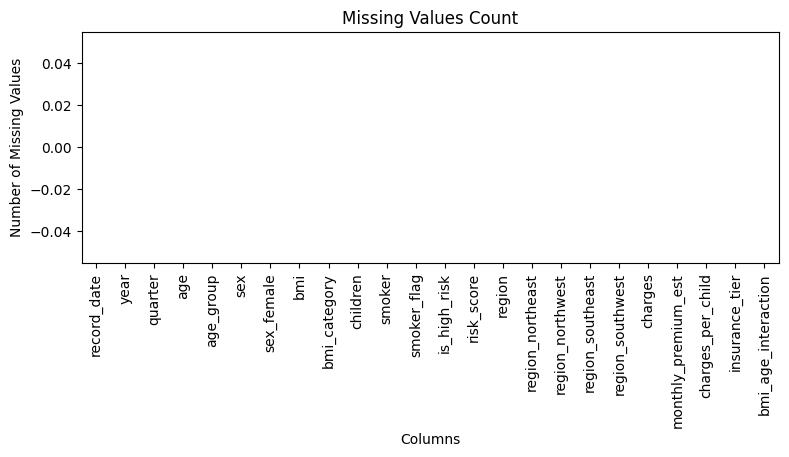

In [ ]:
# Visualizing the missing values
df.isnull().sum().plot(kind='bar', figsize=(9,3))
plt.title("Missing Values Count")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

### What did you know about your dataset?

* *The dataset contains 1,337 observations and 24 variables.*
* *It includes demographic, health-related, and insurance information of individuals.*
* *The target variable is 'charges', which represents the medical insurance cost.*
* *The dataset contains both numerical and categorical variables.*
* *No missing values or duplicate records were found, indicating that the dataset is clean and suitable for analysis.*
* *Some variables are engineered features such as risk_score, bmi_age_interaction, monthly_premium_est, charges_per_child, and insurance_tier, which require careful examination before model building to avoid target leakage.*

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['record_date', 'year', 'quarter', 'age', 'age_group', 'sex',
       'sex_female', 'bmi', 'bmi_category', 'children', 'smoker',
       'smoker_flag', 'is_high_risk', 'risk_score', 'region',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'charges', 'monthly_premium_est',
       'charges_per_child', 'insurance_tier', 'bmi_age_interaction'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,year,quarter,age,sex_female,bmi,children,smoker_flag,is_high_risk,risk_score,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,bmi_age_interaction
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,2023.036649,2.477936,39.222139,0.495138,30.663628,1.095737,0.204936,0.624533,3.052939,0.242334,0.242334,0.272251,0.243082,13279.121503,1106.593328,5127.538257,1212.054233
std,1.384042,1.121910,14.044333,0.500163,6.100233,1.205571,0.403806,0.484425,1.981412,0.428655,0.428655,0.445285,0.429104,12110.359677,1009.196560,8357.618626,522.515951
min,2021.000000,1.000000,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.870000,93.490000,0.000000,287.280000
25%,2022.000000,1.000000,27.000000,0.000000,26.290000,0.000000,0.000000,0.000000,1.690000,0.000000,0.000000,0.000000,0.000000,4746.340000,395.530000,0.000000,765.700000
50%,2023.000000,2.000000,39.000000,0.000000,30.400000,1.000000,0.000000,1.000000,2.480000,0.000000,0.000000,0.000000,0.000000,9386.160000,782.180000,2174.730000,1154.400000
75%,2024.000000,4.000000,51.000000,1.000000,34.700000,2.000000,0.000000,1.000000,3.410000,0.000000,0.000000,1.000000,0.000000,16657.720000,1388.140000,6399.980000,1589.280000
max,2025.000000,4.000000,64.000000,1.000000,53.130000,5.000000,1.000000,1.000000,8.320000,1.000000,1.000000,1.000000,1.000000,63770.430000,5314.200000,58571.070000,2845.480000


### Variables Description

* *record_date: Date on which the insurance record was created.*
* *year: Year of the insurance record.*
* *quarter: Quarter of the year in which the record was created.*
* *age: Age of the insured individual.*
* *age_group: Age category of the insured person.*
* *sex: Gender of the insured person.*
* *sex_female: Encoded gender variable (1 = Female, 0 = Male).*
* *bmi: Body Mass Index of the insured person.*
* *bmi_category: Category of BMI such as Underweight, Normal, Overweight, or Obese.*
* *children: Number of dependent children covered by insurance.*
* *smoker: Smoking status of the insured person.*
* *smoker_flag: Encoded smoking status (1 = Smoker, 0 = Non-smoker).*
* *is_high_risk: Indicates whether the individual belongs to the high-risk category.*
* *risk_score: Calculated health risk score based on various health factors.
* *region: Residential region of the insured individual.*
* *region_northeast: Indicates whether the individual belongs to the Northeast region.*
*region_northwest: Indicates whether the individual belongs to the Northwest region.*
*region_southeast: Indicates whether the individual belongs to the Southeast region.*
*region_southwest: Indicates whether the individual belongs to the Southwest region.*
*charges: Medical insurance charges (Target Variable).*
*monthly_premium_est: Estimated monthly insurance premium.*
*charges_per_child: Average insurance charge per child.*
*insurance_tier: Insurance membership category.*
*bmi_age_interaction: Interaction feature obtained by multiplying BMI and Age.*

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

record_date: 932 unique values
year: 5 unique values
quarter: 4 unique values
age: 47 unique values
age_group: 5 unique values
sex: 2 unique values
sex_female: 2 unique values
bmi: 528 unique values
bmi_category: 6 unique values
children: 6 unique values
smoker: 2 unique values
smoker_flag: 2 unique values
is_high_risk: 2 unique values
risk_score: 514 unique values
region: 4 unique values
region_northeast: 2 unique values
region_northwest: 2 unique values
region_southeast: 2 unique values
region_southwest: 2 unique values
charges: 1337 unique values
monthly_premium_est: 1336 unique values
charges_per_child: 765 unique values
insurance_tier: 5 unique values
bmi_age_interaction: 1260 unique values


### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


record_date
['2024-02-01' '2024-12-30' '2023-05-11' '2024-07-18' '2024-02-05'
 '2024-01-01' '2025-09-21' '2023-11-11' '2025-06-27' '2021-05-02'
 '2022-04-12' '2024-05-23' '2021-11-27' '2025-01-22' '2021-03-29'
 '2024-10-28' '2024-01-29' '2023-05-22' '2025-08-15' '2021-05-11'
 '2025-08-13' '2024-08-25' '2023-02-09' '2021-12-10' '2025-02-24'
 '2024-12-08' '2023-03-17' '2022-01-21' '2024-04-30' '2023-08-14'
 '2021-10-04' '2024-03-30' '2022-04-05' '2024-08-30' '2021-01-22'
 '2021-09-10' '2023-01-18' '2023-05-07' '2025-05-04' '2022-04-20'
 '2023-12-19' '2022-05-26' '2025-09-02' '2025-02-08' '2022-12-01'
 '2023-09-03' '2025-12-12' '2021-07-09' '2023-08-16' '2022-11-18'
 '2022-07-17' '2025-05-10' '2024-06-21' '2023-04-12' '2025-03-09'
 '2024-02-29' '2025-02-17' '2022-10-09' '2021-01-21' '2023-04-21'
 '2021-06-16' '2024-07-21' '2022-01-23' '2022-08-24' '2021-11-12'
 '2021-01-14' '2021-08-30' '2023-02-16' '2024-10-01' '2022-07-19'
 '2023-06-17' '2024-09-25' '2021-04-02' '2024-10-22' '2025-01-1

### What all manipulations have you done and insights you found?

* *Inspected the dataset to understand its structure and data types.*
* *Checked for missing values and found that the dataset contains no null values.*
* *Verified that there are no duplicate records.*
* *Examined the unique values of each variable to understand their distributions and categories.*
* *No cleaning operations such as handling missing values or removing duplicates were required because the dataset is already clean.*

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

/tmp/ipykernel_849/3978698927.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='year', data=df, palette='viridis')


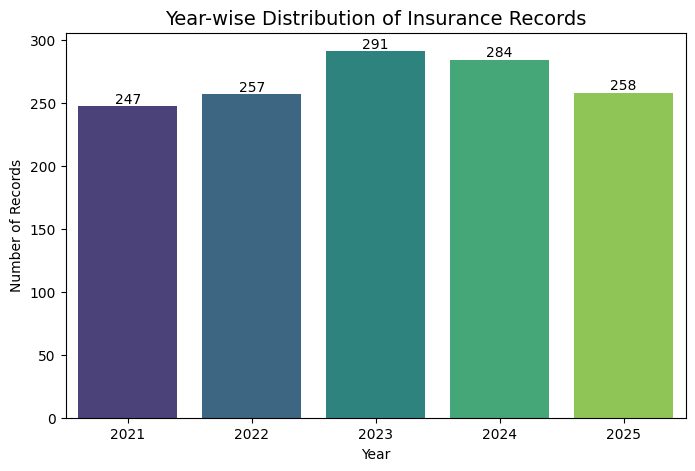

In [4]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))

ax = sns.countplot(x='year', data=df, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10)

plt.title("Year-wise Distribution of Insurance Records", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.show()

##### 1. Why did you pick the specific chart?

* *A bar chart is used to compare the number of insurance records across different years.*
* *It clearly shows how the dataset is distributed over time.*

##### 2. What is/are the insight(s) found from the chart?

* *The highest number of insurance records was observed in 2023.*

* *2024 had the second-highest number of records.*

* *2022 and 2025 have nearly similar record counts.*

* *2021 has the lowest number of records in the dataset.*
* *The variation in the number of records across years is likely due to differences in data collection or the number of policy records included in the dataset rather than actual changes in healthcare demand.*
* *Without additional contextual information, the exact reason for the higher number of records in 2023 cannot be concluded.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Understanding the distribution of insurance records across years helps insurance companies identify periods with higher customer activity.*
* *This can assist in resource allocation, workforce planning, and demand forecasting.*

**Negative Growth**

* *No significant negative growth can be concluded because the chart only shows the distribution of records across years and does not represent business performance or revenue trends.*

#### Chart - 2

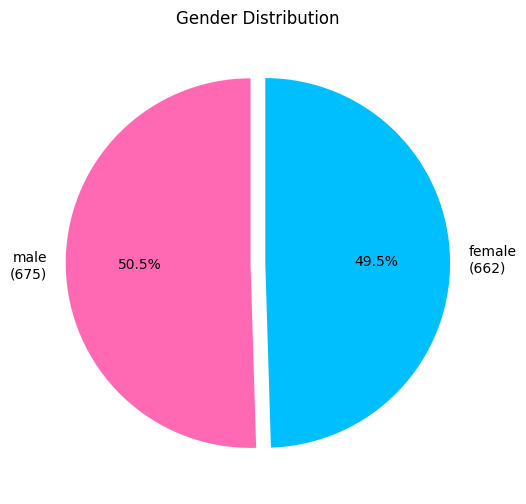

In [5]:
# Chart - 2 visualization code
gender = df['sex'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=[f"{i}\n({v})" for i, v in zip(gender.index, gender.values)],
    autopct="%1.1f%%",
    colors=["hotpink","deepskyblue"],
    startangle=90,
    explode=(0.04,0.04)
)

plt.title("Gender Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

*A pie chart effectively represents the proportion of male and female policyholders, making it easy to compare their relative distribution.*

##### 2. What is/are the insight(s) found from the chart?

* *The dataset contains 50.5% males and 49.5% females.*

* *The gender distribution is nearly balanced, indicating that the dataset does not exhibit significant gender imbalance.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* *A balanced gender distribution ensures that the machine learning model is trained on representative data from both genders, reducing bias and improving the fairness of insurance cost predictions.*

#### Chart - 3

/tmp/ipykernel_849/2980543157.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


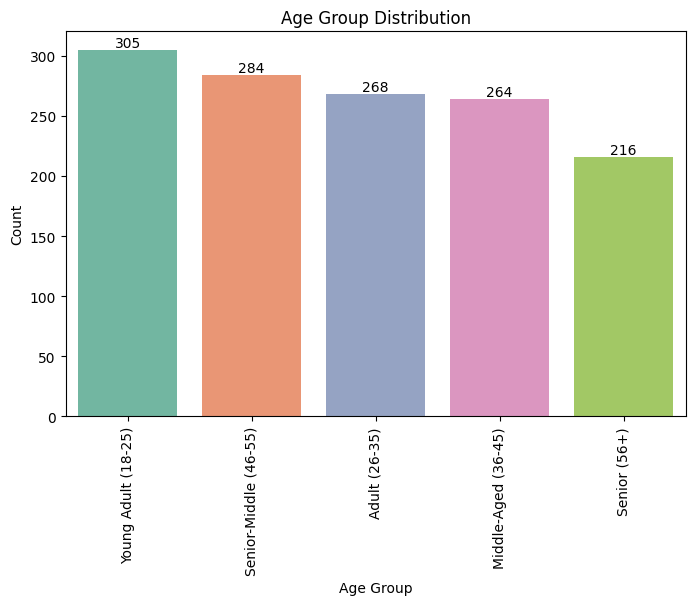

In [6]:
# Chart - 3 visualization code
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='age_group',
    data=df,
    order=df['age_group'].value_counts().index,
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom')

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.xticks(rotation=90)
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

* *A bar chart is suitable for comparing the frequency of individuals across different age groups.*

##### 2. What is/are the insight(s) found from the chart?

* *Young Adults represent the largest group in the dataset.*
* *This is followed by Senior-Middle, Adult, Middle-Aged individuals, and finally the 56+ age group.*
* *The dataset contains a larger proportion of younger individuals compared to older age groups.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**
* *Understanding the age distribution helps insurance companies design age-specific insurance plans, estimate healthcare demand, and develop targeted premium strategies for different customer groups.*

**Negative Growth**
* *The age distribution simply represents the composition of the insured population and does not imply negative business growth.*

#### Chart - 4

/tmp/ipykernel_849/2094293830.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


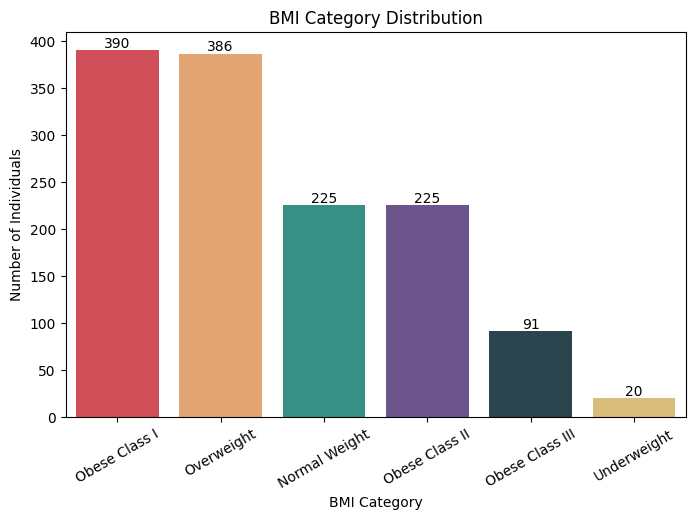

In [7]:
# Chart - 4 visualization code
plt.figure(figsize=(8,5))

colors = ['#e63946','#f4a261','#2a9d8f','#6a4c93','#264653','#e9c46a']

ax = sns.countplot(
    x='bmi_category',
    data=df,
    order=df['bmi_category'].value_counts().index,
    palette=colors
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=30)

plt.title("BMI Category Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Number of Individuals")

plt.show()

##### 1. Why did you pick the specific chart?

*A bar chart is suitable for comparing the number of individuals across different BMI categories, making it easy to identify the most common BMI groups in the dataset.*

##### 2. What is/are the insight(s) found from the chart?

* *Obese Class 1 has the highest number of insured individuals.*

* *It is followed by Overweight and Normal Weight categories.*

* *Obese Class 2 and Obese Class 3 have comparatively fewer individuals.*

* *Underweight has the lowest number of policyholders.*

* *The distribution indicates that a large proportion of insured individuals fall into overweight or obese BMI categories.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**
* *BMI is a significant factor in assessing health risks.*
* *A higher number of overweight and obese individuals can help insurance companies design personalized premium plans, preventive health programs, and wellness initiatives.*

**Negative Growth**
* *Since a large portion of policyholders fall into overweight and obese categories, insurance companies may experience higher medical claims and healthcare costs, which can reduce profitability if not managed effectively*.

#### Chart - 5

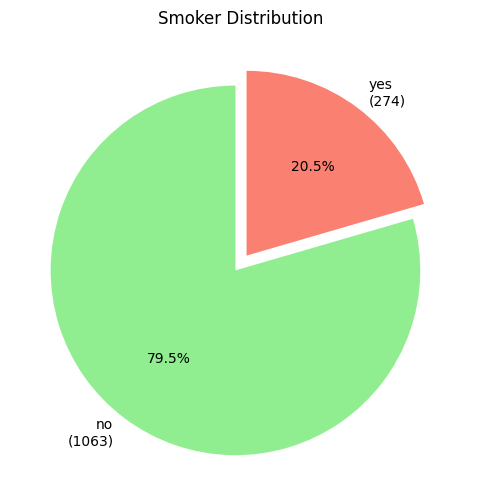

In [ ]:
# Chart - 5 visualization code
smoker=df['smoker'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    smoker,
    labels=[f'{i}\n({v})' for i,v in zip(smoker.index,smoker.values)],
    autopct='%1.1f%%',
    explode=(0.05,0.05),
    colors=['lightgreen','salmon'],
    startangle=90
)

plt.title("Smoker Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

*A pie chart effectively represents the proportion of smokers and non-smokers, allowing easy comparison of their distribution.*

##### 2. What is/are the insight(s) found from the chart?

* *79.5% of the insured individuals are non-smokers.*

* *Only 20.5% are smokers.*

* *The dataset is predominantly composed of non-smokers, indicating that smoking is less common among the insured population.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**
* *Since the majority of customers are non-smokers, insurance companies can expect a relatively healthier customer base.*
* *Smoking status can also be incorporated into premium calculations and targeted wellness programs.*

**Negative Growth**
* *Although smokers represent only a small proportion of the dataset, they are generally associated with higher healthcare costs and increased insurance claims, which can negatively impact the company's financial performance.*

#### Chart - 6

/tmp/ipykernel_849/744423796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(


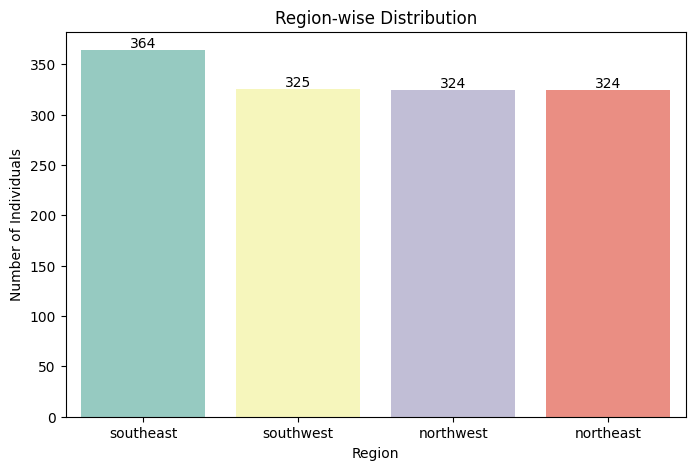

In [8]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))

ax=sns.countplot(
    x='region',
    data=df,
    order=df['region'].value_counts().index,
    palette='Set3'
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Region-wise Distribution")
plt.xlabel("Region")
plt.ylabel("Number of Individuals")

plt.show()

##### 1. Why did you pick the specific chart?

*A bar chart is appropriate for comparing the number of insured individuals across different geographical regions.*

##### 2. What is/are the insight(s) found from the chart?

* *Southeast has the highest number of policyholders.*

* *It is followed by Southwest, Northwest, and Northeast.*

* *The differences between regions are relatively small, indicating that the dataset has a fairly balanced regional distribution.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**
* *Understanding regional distribution helps insurance companies allocate resources efficiently, design region-specific marketing strategies, and ensure that services are available where demand is higher.*

**Negative Growth**
* *No significant negative growth is observed from the regional distribution alone.*
* *However, if future data becomes concentrated in a single region, it may limit the model's ability to generalize well across different geographical areas.*

#### Chart - 7

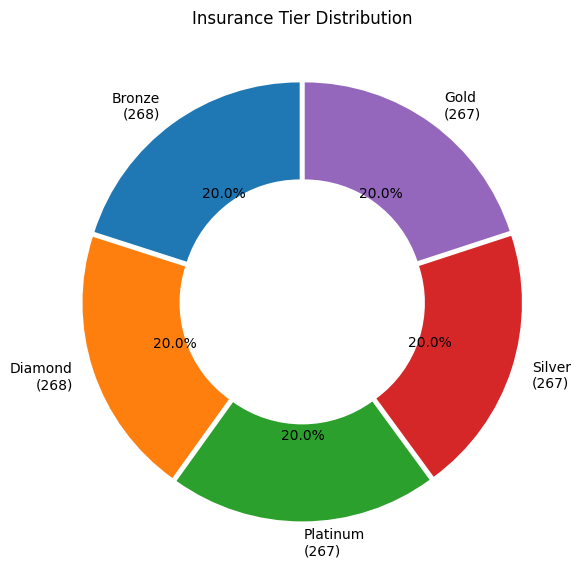

In [9]:
# Chart - 7 visualization code
tier = df['insurance_tier'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=[f"{i}\n({v})" for i,v in zip(tier.index,tier.values)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45),
    explode=[0.02]*len(tier)
)

plt.title("Insurance Tier Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

*A donut chart was chosen because it clearly shows the proportion of policyholders in each insurance tier while making it easy to compare their distributions.*

##### 2. What is/are the insight(s) found from the chart?

* *All five insurance tiers are almost equally represented in the dataset.*

* *Each tier contains approximately 20% of the total records (267–268 individuals).*

* *The dataset does not show any major imbalance among insurance plans.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Since customers are almost evenly distributed across all insurance tiers, companies can evaluate and compare each plan fairly.*
* *There is no strong imbalance that would require focusing on a particular tier.*

**Negative Growth**

*No significant negative trend is observed because all insurance tiers have nearly equal representation.*

#### Chart - 8

In [15]:
# Chart - 8 visualization code


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [14]:
# Chart - 9 visualization code


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

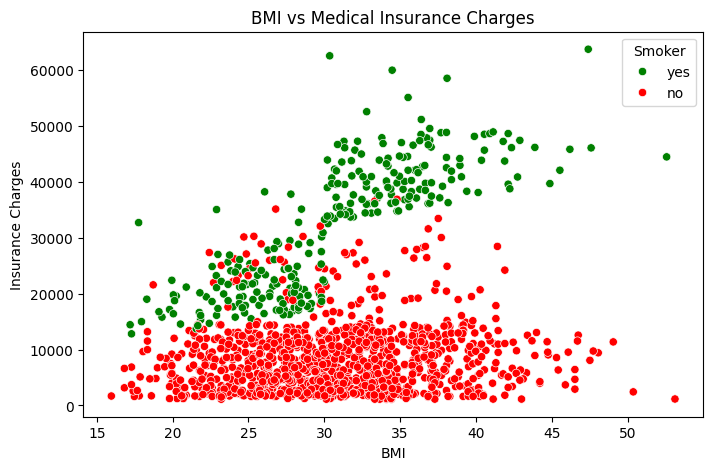

In [12]:
# Chart - 10 visualization code
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='bmi',
    y='charges',
    hue='smoker',
    data=df,
    palette=['green','red']
)

plt.title("BMI vs Medical Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.legend(title="Smoker")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***